In [18]:
import pandas as pd

shots = pd.read_csv('../data/all_players_shots.csv')

a = shots[shots['SHOT_ZONE_BASIC'] != 'Backcourt']

a['SHOT_ZONE_BASIC'].unique()


array(['Above the Break 3', 'Mid-Range', 'In The Paint (Non-RA)',
       'Restricted Area', 'Left Corner 3', 'Right Corner 3'], dtype=object)

Stephen Curry's ID: 201939

First few shots:
           GRID_TYPE     GAME_ID  GAME_EVENT_ID  PLAYER_ID    PLAYER_NAME  \
0  Shot Chart Detail  0022200002             61     201939  Stephen Curry   
1  Shot Chart Detail  0022200002             64     201939  Stephen Curry   
2  Shot Chart Detail  0022200002             68     201939  Stephen Curry   
3  Shot Chart Detail  0022200002            102     201939  Stephen Curry   
4  Shot Chart Detail  0022200002            132     201939  Stephen Curry   

      TEAM_ID              TEAM_NAME  PERIOD  MINUTES_REMAINING  \
0  1610612744  Golden State Warriors       1                  7   
1  1610612744  Golden State Warriors       1                  7   
2  1610612744  Golden State Warriors       1                  7   
3  1610612744  Golden State Warriors       1                  5   
4  1610612744  Golden State Warriors       1                  3   

   SECONDS_REMAINING  ...        SHOT_ZONE_AREA  SHOT_ZONE_RANGE  \
0                 27 

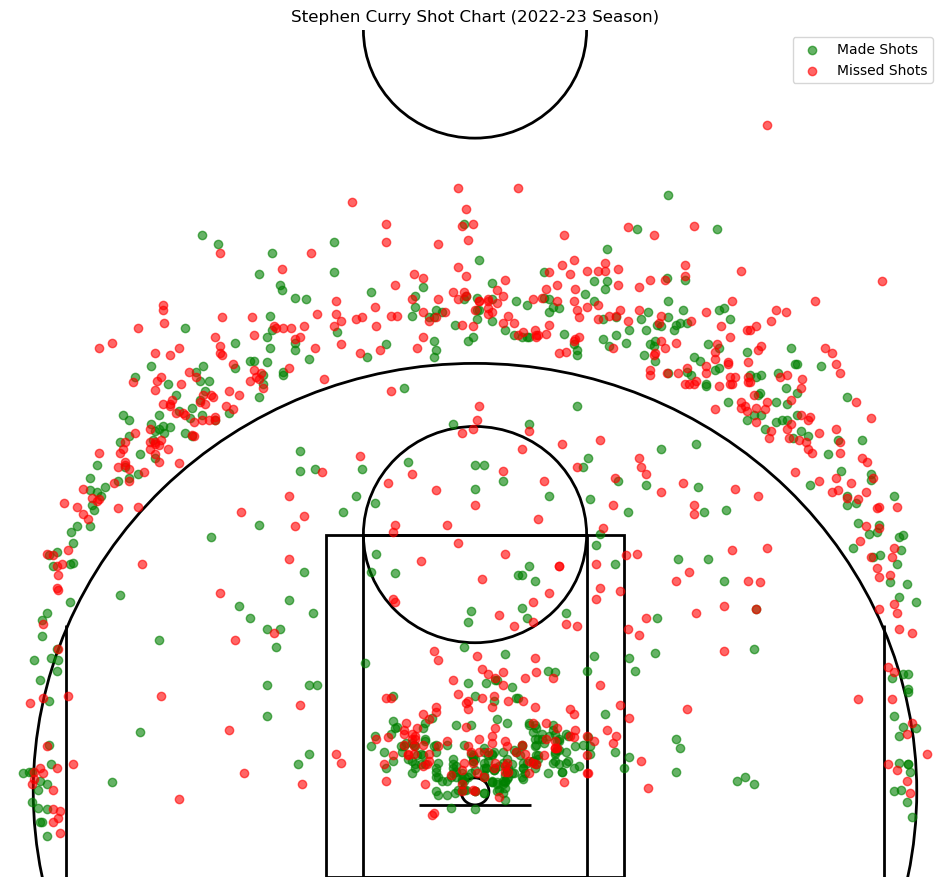


Shooting Percentages by Zone:
                                SHOT_ZONE  ATTEMPTS  MADE  FG_PCT
Above the Break 3 - Right Side Center(RC)       210    89    42.4
 Above the Break 3 - Left Side Center(LC)       189    82    43.4
        In The Paint (Non-RA) - Center(C)       176    91    51.7
              Restricted Area - Center(C)       170   124    72.9
            Above the Break 3 - Center(C)       165    62    37.6
             Left Corner 3 - Left Side(L)        38    22    57.9
        Mid-Range - Right Side Center(RC)        32    13    40.6
                    Mid-Range - Center(C)        31    12    38.7
                 Mid-Range - Left Side(L)        28    17    60.7
                Mid-Range - Right Side(R)        27    13    48.1
           Right Corner 3 - Right Side(R)        27    17    63.0
         Mid-Range - Left Side Center(LC)        18    10    55.6
    In The Paint (Non-RA) - Right Side(R)        12     5    41.7
               Backcourt - Back Court(BC)    

In [1]:
# Import required libraries
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# Get Stephen Curry's player ID
player_dict = players.find_players_by_full_name('Stephen Curry')[0]
player_id = player_dict['id']
print(f"Stephen Curry's ID: {player_id}")

# Get shot chart data for the 2022-23 regular season
shot_json = shotchartdetail.ShotChartDetail(
    team_id=0,
    player_id=player_id,
    season_nullable='2022-23',
    context_measure_simple='FGA'  # Field Goal Attempts
)

# Convert to DataFrame
shots_df = shot_json.get_data_frames()[0]
print("\nFirst few shots:")
print(shots_df.head())

# Create a basketball court visualization
def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()

    # Basketball hoop
    hoop = plt.Circle((0, 0), 7.5, facecolor='none', edgecolor=color, linewidth=lw)
    
    # Backboard
    backboard = plt.Rectangle((-30, -7.5), 60, 0, linewidth=lw, color=color)
    
    # The paint
    outer_box = plt.Rectangle((-80, -47.5), 160, 190, linewidth=lw, facecolor='none', edgecolor=color)
    inner_box = plt.Rectangle((-60, -47.5), 120, 190, linewidth=lw, facecolor='none', edgecolor=color)
    
    # Free throw circle
    top_free_throw = plt.Circle((0, 142.5), 60, facecolor='none', edgecolor=color, linewidth=lw)
    
    # Three point line
    corner_three_a = plt.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = plt.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = plt.Circle((0, 0), 237.5, facecolor='none', edgecolor=color, linewidth=lw)
    
    # Center court
    center_outer = plt.Circle((0, 422.5), 60, facecolor='none', edgecolor=color, linewidth=lw)
    
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                     corner_three_a, corner_three_b, three_arc, center_outer]

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    
    return ax

# Plot Curry's shots
plt.figure(figsize=(12, 11))
ax = plt.gca()
draw_court(ax)

# Plot made shots
made_shots = shots_df[shots_df['SHOT_MADE_FLAG'] == 1]
missed_shots = shots_df[shots_df['SHOT_MADE_FLAG'] == 0]

plt.scatter(made_shots['LOC_X'], made_shots['LOC_Y'], c='green', alpha=0.6, label='Made Shots')
plt.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'], c='red', alpha=0.6, label='Missed Shots')

plt.title(f"Stephen Curry Shot Chart (2022-23 Season)")
plt.legend()
plt.axis('off')
plt.show()

# Calculate shooting percentages by zone
shots_df['SHOT_ZONE'] = shots_df.apply(
    lambda row: f"{row['SHOT_ZONE_BASIC']} - {row['SHOT_ZONE_AREA']}", axis=1
)

zone_stats = shots_df.groupby('SHOT_ZONE').agg({
    'SHOT_MADE_FLAG': ['count', 'sum']
}).reset_index()

zone_stats.columns = ['SHOT_ZONE', 'ATTEMPTS', 'MADE']
zone_stats['FG_PCT'] = (zone_stats['MADE'] / zone_stats['ATTEMPTS'] * 100).round(1)
zone_stats = zone_stats.sort_values('ATTEMPTS', ascending=False)

print("\nShooting Percentages by Zone:")
print(zone_stats.to_string(index=False))

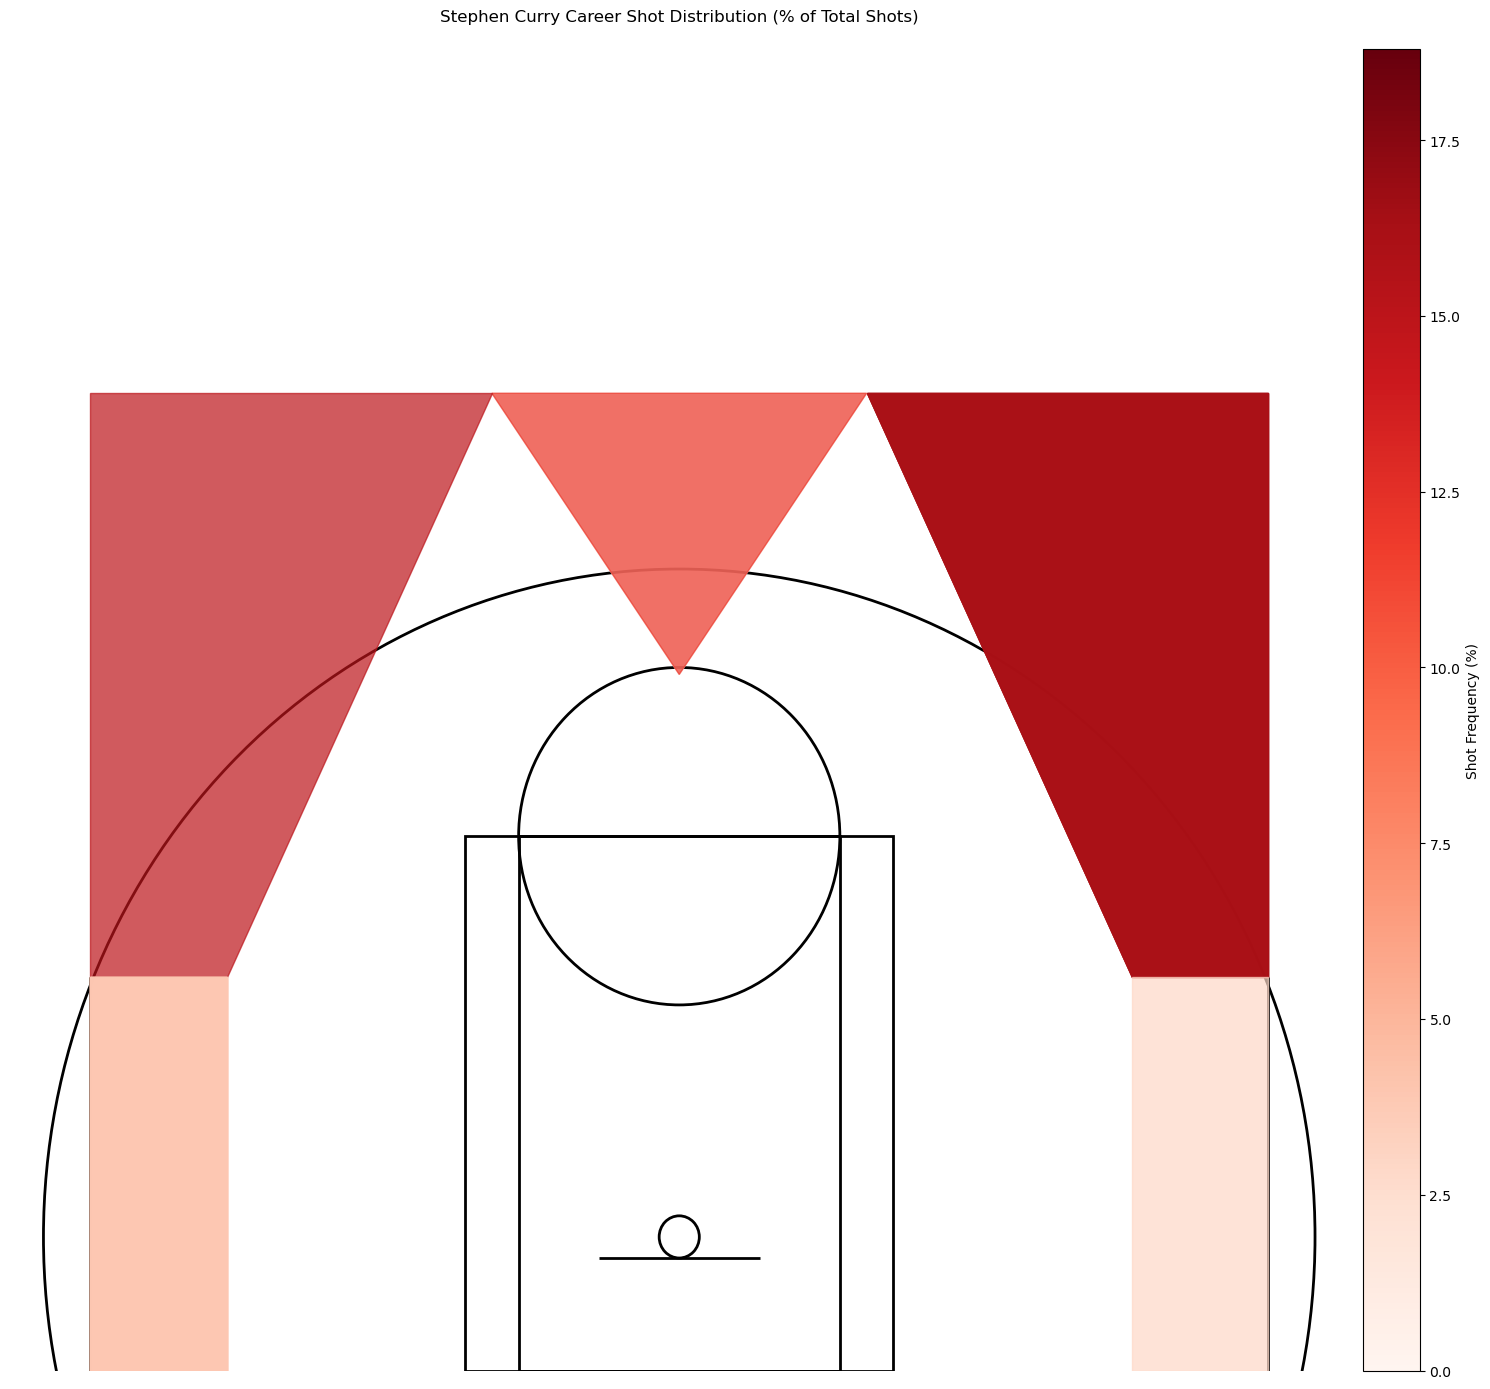


Detailed Shot Distribution by Zone:
                                           Shot Frequency (%)  Total Shots
SHOT_ZONE                                                                 
Restricted Area - Center(C)                              18.8         2942
Above the Break 3 - Right Side Center(RC)                16.1         2520
Above the Break 3 - Left Side Center(LC)                 15.0         2346
Above the Break 3 - Center(C)                            12.0         1875
In The Paint (Non-RA) - Center(C)                         8.8         1374
Mid-Range - Right Side Center(RC)                         5.0          786
Mid-Range - Left Side Center(LC)                          4.2          652
Mid-Range - Center(C)                                     4.0          626
Left Corner 3 - Left Side(L)                              3.9          618
Mid-Range - Left Side(L)                                  3.8          590
Mid-Range - Right Side(R)                                 3.8  

In [3]:
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get Stephen Curry's player ID
player_dict = players.find_players_by_full_name('Stephen Curry')[0]
player_id = player_dict['id']

# Get shot chart data for Curry's entire career
shot_json = shotchartdetail.ShotChartDetail(
    team_id=0,
    player_id=player_id,
    context_measure_simple='FGA',  # Field Goal Attempts
    season_nullable='2009-10',  # His rookie season
    season_type_all_star='Regular Season'
)

# Convert to DataFrame and start with 2009-10 season
shots_df = shot_json.get_data_frames()[0]

# Get data for all subsequent seasons through 2022-23
for season in [f"{year}-{str(year+1)[2:]}" for year in range(2010, 2023)]:
    try:
        season_shots = shotchartdetail.ShotChartDetail(
            team_id=0,
            player_id=player_id,
            context_measure_simple='FGA',
            season_nullable=season,
            season_type_all_star='Regular Season'
        ).get_data_frames()[0]
        shots_df = pd.concat([shots_df, season_shots])
    except:
        continue

# Create court drawing function
def draw_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    # Basketball hoop
    hoop = plt.Circle((0, 0), 7.5, facecolor='none', edgecolor=color, linewidth=lw)
    
    # Backboard
    backboard = plt.Rectangle((-30, -7.5), 60, 0, linewidth=lw, color=color)
    
    # The paint
    outer_box = plt.Rectangle((-80, -47.5), 160, 190, linewidth=lw, facecolor='none', edgecolor=color)
    inner_box = plt.Rectangle((-60, -47.5), 120, 190, linewidth=lw, facecolor='none', edgecolor=color)
    
    # Free throw circle
    top_free_throw = plt.Circle((0, 142.5), 60, facecolor='none', edgecolor=color, linewidth=lw)
    
    # Three point line
    corner_three_a = plt.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = plt.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = plt.Circle((0, 0), 237.5, facecolor='none', edgecolor=color, linewidth=lw)
    
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                     corner_three_a, corner_three_b, three_arc]

    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    
    return ax

# Calculate shot frequency by zone
shots_df['SHOT_ZONE'] = shots_df['SHOT_ZONE_BASIC'] + ' - ' + shots_df['SHOT_ZONE_AREA']
zone_freq = shots_df.groupby('SHOT_ZONE').size()
total_shots = len(shots_df)
zone_freq_pct = (zone_freq / total_shots * 100).round(1)

# Create figure with a specific size and layout for colorbar
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(1, 20)  # Create 20 columns
ax_court = fig.add_subplot(gs[:, :-1])  # Use all but last column for court
ax_cbar = fig.add_subplot(gs[:, -1])  # Use last column for colorbar

draw_court(ax_court)

# Create a dictionary to store zone centers for text placement
zone_centers = {
    'Above the Break 3 - Center': (0, 250),
    'Above the Break 3 - Left Side': (-170, 250),
    'Above the Break 3 - Right Side': (170, 250),
    'Corner 3 - Left Side': (-220, 0),
    'Corner 3 - Right Side': (220, 0),
    'Mid-Range - Center': (0, 150),
    'Mid-Range - Left Side': (-140, 100),
    'Mid-Range - Left Side Center': (-90, 150),
    'Mid-Range - Right Side': (140, 100),
    'Mid-Range - Right Side Center': (90, 150),
    'In The Paint (Non-RA) - Center': (0, 70),
    'Restricted Area - Center': (0, 25),
    'Backcourt - Center': (0, 350)
}

# Create custom polygons for each zone and fill them with colors based on frequency
norm = plt.Normalize(vmin=0, vmax=max(zone_freq_pct))
cmap = plt.cm.Reds

for zone in zone_freq_pct.index:
    if 'Backcourt' in zone:
        continue  # Skip backcourt shots
        
    freq = zone_freq_pct[zone]
    color = cmap(norm(freq))
    
    # Create zone-specific polygons
    if 'Corner 3' in zone:
        if 'Left' in zone:
            polygon = plt.Polygon([(-220, -47.5), (-220, 92.5), (-169, 92.5), (-169, -47.5)],
                                alpha=0.7, color=color)
        else:
            polygon = plt.Polygon([(220, -47.5), (220, 92.5), (169, 92.5), (169, -47.5)],
                                alpha=0.7, color=color)
    
    elif 'Above the Break 3' in zone:
        if 'Left' in zone:
            polygon = plt.Polygon([(-169, 92.5), (-220, 92.5), (-220, 300), (-70, 300)],
                                alpha=0.7, color=color)
        elif 'Right' in zone:
            polygon = plt.Polygon([(169, 92.5), (220, 92.5), (220, 300), (70, 300)],
                                alpha=0.7, color=color)
        else:
            polygon = plt.Polygon([(-70, 300), (70, 300), (0, 200)],
                                alpha=0.7, color=color)
    
    ax_court.add_patch(polygon)
    
    # Add text with percentage
    if zone in zone_centers:
        x, y = zone_centers[zone]
        ax_court.text(x, y, f'{freq:.1f}%', horizontalalignment='center', 
                     verticalalignment='center', color='black', fontweight='bold')

ax_court.set_title("Stephen Curry Career Shot Distribution (% of Total Shots)", pad=20)
ax_court.axis('off')

# Add colorbar
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), 
            cax=ax_cbar, label='Shot Frequency (%)')

plt.tight_layout()
plt.show()

# Print detailed zone statistics
print("\nDetailed Shot Distribution by Zone:")
zone_stats = pd.DataFrame({
    'Shot Frequency (%)': zone_freq_pct,
    'Total Shots': zone_freq
}).sort_values('Shot Frequency (%)', ascending=False)
print(zone_stats)

In [13]:
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players

# First, let's get a valid player ID (let's use Stephen Curry as an example)
player_dict = players.find_players_by_full_name('Stephen Curry')[0]
player_id = player_dict['id']

# Get the Warriors team ID
team_id = 1610612744  # Golden State Warriors

# Get shot chart data
shot_chart = shotchartdetail.ShotChartDetail(
    team_id=team_id,
    player_id=player_id,
    season_nullable='2022-23',
    season_type_all_star='Regular Season',
    context_measure_simple='FGA'
)

# Convert to DataFrame
shots_df = shot_chart.get_data_frames()[0]

# Print the shape to confirm we have data
print(f"Number of shots: {len(shots_df)}")

# Print first few rows to see the data
shots_df[['SHOT_ZONE_AREA', 'SHOT_ZONE_BASIC', 'LOC_X', 'LOC_Y']]

Number of shots: 1133


,SHOT_ZONE_AREA,SHOT_ZONE_BASIC,LOC_X,LOC_Y
0,Center(C),In The Paint (Non-RA),60,10
1,Right Side(R),Mid-Range,150,79
2,Center(C),Above the Break 3,7,273
3,Left Side Center(LC),Above the Break 3,-151,197
4,Left Side Center(LC),Above the Break 3,-81,229
...,...,...,...,...
1128,Left Side Center(LC),Above the Break 3,-172,223
1129,Right Side Center(RC),Above the Break 3,121,239
1130,Center(C),Restricted Area,33,15
1131,Left Side(L),Left Corner 3,-225,79


In [14]:
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd

# Get Curry's player ID
curry = players.find_players_by_full_name('Stephen Curry')[0]
player_id = curry['id']
team_id = 1610612744  # Warriors

# List of all seasons since Curry entered the NBA
seasons = [f'{year}-{str(year+1)[-2:]}' for year in range(2009, 2024)]

# Empty list to store all season dataframes
all_shots = []

# Get data for each season
for season in seasons:
    print(f"Getting data for season {season}...")
    
    shot_chart = shotchartdetail.ShotChartDetail(
        team_id=team_id,
        player_id=player_id,
        season_nullable=season,
        season_type_all_star='Regular Season',
        context_measure_simple='FGA'
    )
    
    # Get the data frame for this season
    season_df = shot_chart.get_data_frames()[0]
    
    # Add season identifier
    season_df['SEASON'] = season
    
    # Append to our list
    all_shots.append(season_df)
    
    # Optional: add a small delay to avoid hitting API rate limits
    import time
    time.sleep(1)

# Combine all seasons into one dataframe
shots_df = pd.concat(all_shots, ignore_index=True)

# Print summary
print(f"\nTotal shots in dataset: {len(shots_df)}")
print("\nShots per season:")
print(shots_df['SEASON'].value_counts().sort_index())

Getting data for season 2009-10...
Getting data for season 2010-11...
Getting data for season 2011-12...
Getting data for season 2012-13...
Getting data for season 2013-14...
Getting data for season 2014-15...
Getting data for season 2015-16...
Getting data for season 2016-17...
Getting data for season 2017-18...
Getting data for season 2018-19...
Getting data for season 2019-20...
Getting data for season 2020-21...
Getting data for season 2021-22...
Getting data for season 2022-23...
Getting data for season 2023-24...

Total shots in dataset: 17095

Shots per season:
SEASON
2009-10    1143
2010-11    1053
2011-12     296
2012-13    1388
2013-14    1383
2014-15    1341
2015-16    1596
2016-17    1442
2017-18     864
2018-19    1340
2019-20      82
2020-21    1365
2021-22    1224
2022-23    1133
2023-24    1445
Name: count, dtype: int64


In [21]:
shots_df[['SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'LOC_X', 'LOC_Y']]

shots_df['SHOT_ZONE_BASIC'].unique()

array(['Above the Break 3', 'Mid-Range', 'In The Paint (Non-RA)',
       'Restricted Area', 'Left Corner 3', 'Right Corner 3', 'Backcourt'],
      dtype=object)

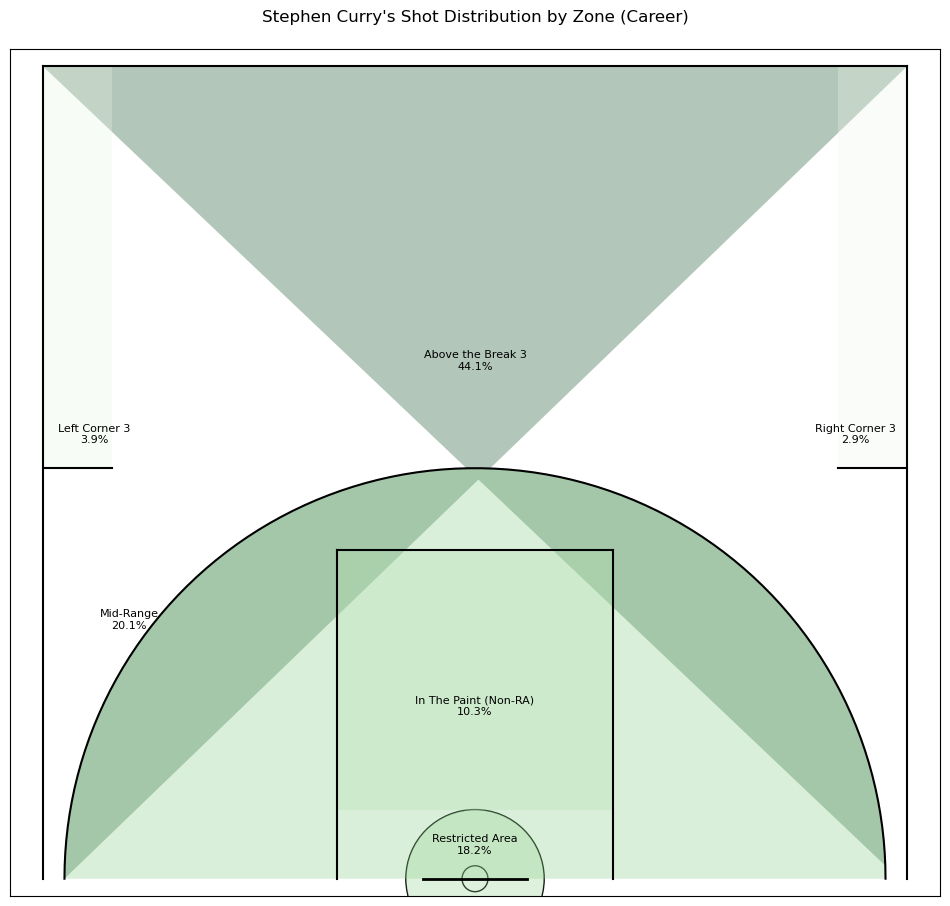

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate shot frequencies and percentages for each zone
zone_stats = shots_df.groupby('SHOT_ZONE_BASIC').size()
zone_percentages = (zone_stats / len(shots_df)) * 100

# Create figure and axis
fig = plt.figure(figsize=(12, 11))
ax = fig.add_subplot(1, 1, 1)

# Court dimensions
court_width = 50
court_height = 47
three_point_radius = 23.75
three_point_line_width = 0.1
key_width = 16
key_height = 19
backboard_width = 6
backboard_to_three_point_line = 4
rim_radius = 0.75
restricted_area_radius = 4

# Draw court outline
plt.plot([-court_width/2, -court_width/2], [0, court_height], 'black')
plt.plot([court_width/2, court_width/2], [0, court_height], 'black')
plt.plot([-court_width/2, court_width/2], [court_height, court_height], 'black')

# Calculate three point line points
angle = np.linspace(0, np.pi, 100)
three_point_x = three_point_radius * np.cos(angle)
three_point_y = three_point_radius * np.sin(angle)

# Draw three point line
plt.plot(three_point_x, three_point_y, 'black')
plt.plot([-court_width/2, -court_width/2 + backboard_to_three_point_line], 
         [three_point_radius, three_point_radius], 'black')
plt.plot([court_width/2 - backboard_to_three_point_line, court_width/2], 
         [three_point_radius, three_point_radius], 'black')

# Draw key
plt.plot([-key_width/2, -key_width/2], [0, key_height], 'black')
plt.plot([key_width/2, key_width/2], [0, key_height], 'black')
plt.plot([-key_width/2, key_width/2], [key_height, key_height], 'black')

# Draw restricted area
restricted_area = plt.Circle((0, 0), restricted_area_radius, fill=False, color='black')
ax.add_artist(restricted_area)

# Draw backboard
plt.plot([-backboard_width/2, backboard_width/2], [0, 0], 'black', linewidth=2)

# Draw rim
rim = plt.Circle((0, 0), rim_radius, fill=False, color='black')
ax.add_artist(rim)

# Create color patches for each zone
def create_zone_patch(zone):
    if zone == 'Restricted Area':
        return plt.Circle((0, 0), restricted_area_radius, alpha=0.3)
    elif zone == 'In The Paint (Non-RA)':
        return plt.Rectangle((-key_width/2, restricted_area_radius), key_width, key_height-restricted_area_radius, alpha=0.3)
    elif zone == 'Mid-Range':
        # Create polygon for mid-range area
        mid_range_vertices = []
        for i in range(len(three_point_x)):
            if three_point_y[i] <= three_point_radius:
                mid_range_vertices.append([three_point_x[i], three_point_y[i]])
        
        mid_range_vertices = np.array(mid_range_vertices)
        return plt.Polygon(mid_range_vertices, alpha=0.3)
    elif zone == 'Left Corner 3':
        return plt.Rectangle((-court_width/2, three_point_radius), backboard_to_three_point_line, court_height-three_point_radius, alpha=0.3)
    elif zone == 'Right Corner 3':
        return plt.Rectangle((court_width/2-backboard_to_three_point_line, three_point_radius), backboard_to_three_point_line, court_height-three_point_radius, alpha=0.3)
    elif zone == 'Above the Break 3':
        # Create polygon for above the break 3
        above_break_vertices = []
        for i in range(len(three_point_x)):
            if three_point_y[i] > 0:
                above_break_vertices.append([three_point_x[i], three_point_y[i]])
        above_break_vertices.append([court_width/2, court_height])
        above_break_vertices.append([-court_width/2, court_height])
        
        above_break_vertices = np.array(above_break_vertices)
        return plt.Polygon(above_break_vertices, alpha=0.3)
    return None

# Create colormap
cmap = plt.cm.Greens

# Add colored patches for each zone
for zone in zone_percentages.index:
    if zone != 'Backcourt':  # Skip backcourt shots
        patch = create_zone_patch(zone)
        if patch:
            color_intensity = zone_percentages[zone] / zone_percentages.max()
            patch.set_facecolor(cmap(color_intensity))
            ax.add_artist(patch)

# Add zone labels with percentages
zone_centers = {
    'Restricted Area': (0, 2),
    'In The Paint (Non-RA)': (0, 10),
    'Mid-Range': (-20, 15),
    'Left Corner 3': (-22, three_point_radius + 2),
    'Right Corner 3': (22, three_point_radius + 2),
    'Above the Break 3': (0, 30)
}

for zone, (x, y) in zone_centers.items():
    if zone in zone_percentages.index:
        percentage = zone_percentages[zone]
        plt.text(x, y, f'{zone}\n{percentage:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=8)

# Set axis properties
plt.axis('equal')
plt.xlim(-court_width/2 - 1, court_width/2 + 1)
plt.ylim(-1, court_height + 1)
ax.set_xticks([])
ax.set_yticks([])

# Add title
plt.title("Stephen Curry's Shot Distribution by Zone (Career)", pad=20)

plt.show()


Shot distribution by zone:
Above the Break 3: 44.1%
Backcourt: 0.6%
In The Paint (Non-RA): 10.3%
Left Corner 3: 3.9%
Mid-Range: 20.1%
Restricted Area: 18.2%
Right Corner 3: 2.9%


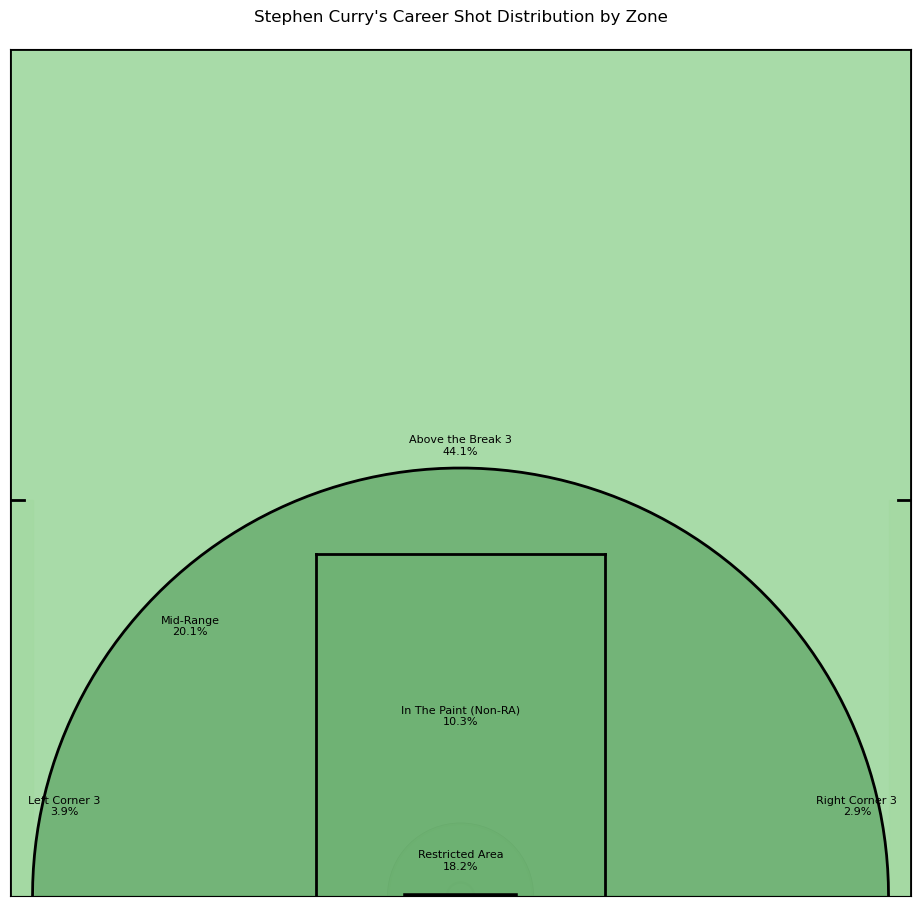

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate percentages for each zone
zone_stats = shots_df.groupby('SHOT_ZONE_BASIC').size()
zone_percentages = (zone_stats / len(shots_df)) * 100

# Print the percentages to verify
print("\nShot distribution by zone:")
for zone, pct in zone_percentages.items():
    print(f"{zone}: {pct:.1f}%")

def draw_nba_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()
    
    # Court dimensions (all in feet)
    court_width = 50
    court_height = 47
    three_point_radius = 23.75
    three_point_corner = 22
    key_width = 16
    key_height = 19
    restricted_area_radius = 4
    basket_radius = 0.75
    backboard_width = 6
    
    # Create court outline
    ax.plot([-court_width/2, -court_width/2], [0, court_height], color=color, lw=lw)
    ax.plot([court_width/2, court_width/2], [0, court_height], color=color, lw=lw)
    ax.plot([-court_width/2, court_width/2], [court_height, court_height], color=color, lw=lw)
    
    # Draw 3-point arc
    three_point_arc = np.linspace(np.pi, 0, 100)
    three_point_x = three_point_radius * np.cos(three_point_arc)
    three_point_y = three_point_radius * np.sin(three_point_arc)
    ax.plot(three_point_x, three_point_y, color=color, lw=lw)
    
    # Draw 3-point corner lines
    ax.plot([-court_width/2, -court_width/2 + 0.75], [three_point_corner, three_point_corner], color=color, lw=lw)
    ax.plot([court_width/2 - 0.75, court_width/2], [three_point_corner, three_point_corner], color=color, lw=lw)
    
    # Draw key
    ax.plot([-key_width/2, -key_width/2], [0, key_height], color=color, lw=lw)
    ax.plot([key_width/2, key_width/2], [0, key_height], color=color, lw=lw)
    ax.plot([-key_width/2, key_width/2], [key_height, key_height], color=color, lw=lw)
    
    # Draw restricted area
    restricted_arc = plt.Circle((0, 0), restricted_area_radius, fill=False, color=color, lw=lw)
    ax.add_artist(restricted_arc)
    
    # Draw backboard
    ax.plot([-backboard_width/2, backboard_width/2], [0, 0], color=color, lw=lw*2)
    
    # Draw basket
    basket = plt.Circle((0, 0), basket_radius, fill=False, color=color, lw=lw)
    ax.add_artist(basket)
    
    return ax

def create_shot_zones(ax=None):
    if ax is None:
        ax = plt.gca()
        
    # Court dimensions
    court_width = 50
    court_height = 47
    three_point_radius = 23.75
    three_point_corner = 22
    key_width = 16
    key_height = 19
    restricted_area_radius = 4
    
    # Create colormap
    cmap = plt.cm.Greens
    max_pct = zone_percentages.max()
    
    # Map zone names from our data to the drawing functions
    zone_mapping = {
        'Restricted Area': 'Restricted Area',
        'In The Paint (Non-RA)': 'Paint (Non-RA)',
        'Mid-Range': 'Mid-Range',
        'Above the Break 3': 'Above Break 3',
        'Left Corner 3': 'Left Corner 3',
        'Right Corner 3': 'Right Corner 3'
    }
    
    # Create zones with color intensity based on percentages
    # Restricted Area
    restricted = plt.Circle((0, 0), restricted_area_radius, 
                          color=cmap(zone_percentages['Restricted Area']/max_pct), 
                          alpha=0.7)
    ax.add_artist(restricted)
    
    # Paint (Non-RA)
    paint = plt.Rectangle((-key_width/2, 0), key_width, key_height,
                         color=cmap(zone_percentages['In The Paint (Non-RA)']/max_pct), 
                         alpha=0.7)
    ax.add_artist(paint)
    
    # Three point arc
    arc_points = np.linspace(0, np.pi, 100)
    three_x = three_point_radius * np.cos(arc_points)
    three_y = three_point_radius * np.sin(arc_points)
    
    # Above Break 3
    above_break = plt.Polygon(np.column_stack([three_x, three_y]),
                            color=cmap(zone_percentages['Above the Break 3']/max_pct), 
                            alpha=0.7)
    ax.add_artist(above_break)
    
    # Corner 3s
    left_corner = plt.Rectangle((-court_width/2, 0), 
                              court_width/2 - three_point_radius, three_point_corner,
                              color=cmap(zone_percentages['Left Corner 3']/max_pct), 
                              alpha=0.7)
    right_corner = plt.Rectangle((three_point_radius, 0), 
                               court_width/2 - three_point_radius, three_point_corner,
                               color=cmap(zone_percentages['Right Corner 3']/max_pct), 
                               alpha=0.7)
    ax.add_artist(left_corner)
    ax.add_artist(right_corner)
    
    # Mid-Range
    mid_range = plt.Rectangle((-court_width/2, 0), 
                            court_width, court_height,
                            color=cmap(zone_percentages['Mid-Range']/max_pct), 
                            alpha=0.7)
    ax.add_artist(mid_range)
    
    # Add labels with percentages
    labels = {
        'Restricted Area': (0, 2),
        'In The Paint (Non-RA)': (0, 10),
        'Mid-Range': (-15, 15),
        'Above the Break 3': (0, 25),
        'Left Corner 3': (-22, 5),
        'Right Corner 3': (22, 5)
    }
    
    for zone, (x, y) in labels.items():
        percentage = zone_percentages[zone]
        label = f"{zone}\n{percentage:.1f}%"
        ax.text(x, y, label, horizontalalignment='center', 
                verticalalignment='center', fontsize=8)
    
    return ax

# Create the visualization
fig = plt.figure(figsize=(12, 11))
ax = fig.add_subplot(1, 1, 1)

# Draw the court
draw_nba_court(ax)

# Add the shot zones
create_shot_zones(ax)

# Set the plot limits
ax.set_xlim(-25, 25)
ax.set_ylim(0, 47)

# Remove axes
ax.set_xticks([])
ax.set_yticks([])

# Set title
plt.title("Stephen Curry's Career Shot Distribution by Zone", pad=20)

# Make sure the court is drawn with the correct aspect ratio
ax.set_aspect('equal')

plt.show()

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

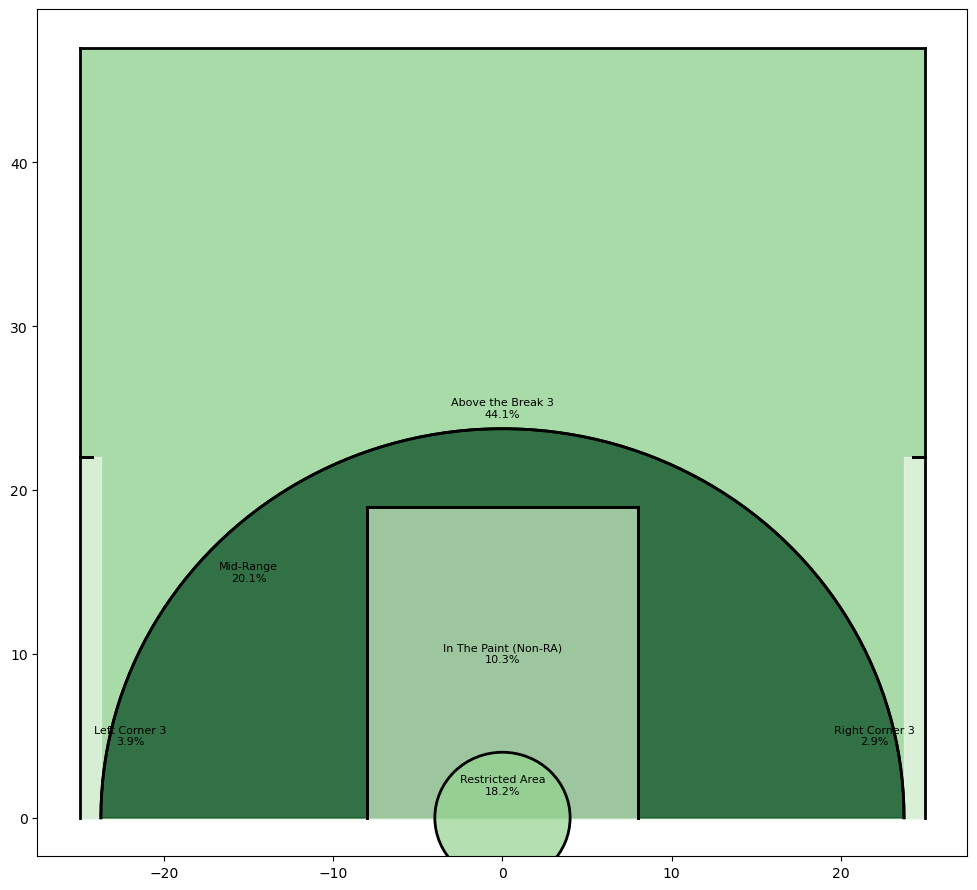

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate percentages for each zone
zone_stats = shots_df.groupby('SHOT_ZONE_BASIC').size()
zone_percentages = (zone_stats / len(shots_df)) * 100

def draw_nba_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()
    
    # Court dimensions (all in feet)
    court_width = 50
    court_height = 47
    three_point_radius = 23.75
    three_point_corner = 22
    key_width = 16
    key_height = 19
    restricted_area_radius = 4
    basket_radius = 0.75
    backboard_width = 6
    
    # Create court outline
    ax.plot([-court_width/2, -court_width/2], [0, court_height], color=color, lw=lw)
    ax.plot([court_width/2, court_width/2], [0, court_height], color=color, lw=lw)
    ax.plot([-court_width/2, court_width/2], [court_height, court_height], color=color, lw=lw)
    
    # Draw 3-point arc
    three_point_arc = np.linspace(np.pi, 0, 100)
    three_point_x = three_point_radius * np.cos(three_point_arc)
    three_point_y = three_point_radius * np.sin(three_point_arc)
    ax.plot(three_point_x, three_point_y, color=color, lw=lw)
    
    # Draw 3-point corner lines
    ax.plot([-court_width/2, -court_width/2 + 0.75], [three_point_corner, three_point_corner], color=color, lw=lw)
    ax.plot([court_width/2 - 0.75, court_width/2], [three_point_corner, three_point_corner], color=color, lw=lw)
    
    # Draw key
    ax.plot([-key_width/2, -key_width/2], [0, key_height], color=color, lw=lw)
    ax.plot([key_width/2, key_width/2], [0, key_height], color=color, lw=lw)
    ax.plot([-key_width/2, key_width/2], [key_height, key_height], color=color, lw=lw)
    
    return ax

def create_shot_zones(ax=None):
    if ax is None:
        ax = plt.gca()
        
    # Court dimensions
    court_width = 50
    court_height = 47
    three_point_radius = 23.75
    three_point_corner = 22
    key_width = 16
    key_height = 19
    restricted_area_radius = 4
    
    # Create colormap with proper normalization
    cmap = plt.cm.Greens
    norm = plt.Normalize(0, zone_percentages.max())
    
    # Draw zones in specific order (back to front)
    
    # 1. Mid-Range (background)
    mid_range = plt.Rectangle((-court_width/2, 0), 
                            court_width, court_height,
                            color=cmap(norm(zone_percentages['Mid-Range'])), 
                            alpha=0.7)
    ax.add_artist(mid_range)
    
    # 2. Above Break 3
    arc_points = np.linspace(0, np.pi, 100)
    three_x = three_point_radius * np.cos(arc_points)
    three_y = three_point_radius * np.sin(arc_points)
    
    above_break = plt.Polygon(np.column_stack([three_x, three_y]),
                            color=cmap(norm(zone_percentages['Above the Break 3'])), 
                            alpha=0.7)
    ax.add_artist(above_break)
    
    # 3. Corner 3s
    left_corner = plt.Rectangle((-court_width/2, 0), 
                              court_width/2 - three_point_radius, three_point_corner,
                              color=cmap(norm(zone_percentages['Left Corner 3'])), 
                              alpha=0.7)
    right_corner = plt.Rectangle((three_point_radius, 0), 
                               court_width/2 - three_point_radius, three_point_corner,
                               color=cmap(norm(zone_percentages['Right Corner 3'])), 
                               alpha=0.7)
    ax.add_artist(left_corner)
    ax.add_artist(right_corner)
    
    # 4. Paint (Non-RA)
    paint = plt.Rectangle((-key_width/2, 0), key_width, key_height,
                         color=cmap(norm(zone_percentages['In The Paint (Non-RA)'])), 
                         alpha=0.7)
    ax.add_artist(paint)
    
    # 5. Restricted Area (front)
    restricted = plt.Circle((0, 0), restricted_area_radius, 
                          color=cmap(norm(zone_percentages['Restricted Area'])), 
                          alpha=0.7)
    ax.add_artist(restricted)
    
    # Draw boundaries
    # Restricted Area
    restricted_arc = plt.Circle((0, 0), restricted_area_radius, fill=False, color='black', lw=2)
    ax.add_artist(restricted_arc)
    
    # Paint
    ax.plot([-key_width/2, -key_width/2], [0, key_height], 'black', lw=2)
    ax.plot([key_width/2, key_width/2], [0, key_height], 'black', lw=2)
    ax.plot([-key_width/2, key_width/2], [key_height, key_height], 'black', lw=2)
    
    # Three point line
    ax.plot(three_x, three_y, 'black', lw=2)
    ax.plot([-court_width/2, -court_width/2 + 0.75], [three_point_corner, three_point_corner], 'black', lw=2)
    ax.plot([court_width/2 - 0.75, court_width/2], [three_point_corner, three_point_corner], 'black', lw=2)
    
    # Add labels with percentages
    labels = {
        'Restricted Area': (0, 2),
        'In The Paint (Non-RA)': (0, 10),
        'Mid-Range': (-15, 15),
        'Above the Break 3': (0, 25),
        'Left Corner 3': (-22, 5),
        'Right Corner 3': (22, 5)
    }
    
    for zone, (x, y) in labels.items():
        percentage = zone_percentages[zone]
        label = f"{zone}\n{percentage:.1f}%"
        ax.text(x, y, label, horizontalalignment='center', 
                verticalalignment='center', fontsize=8)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Percentage of Total Shots')
    
    return ax

# Create the visualization
fig = plt.figure(figsize=(12, 11))
ax = fig.add_subplot(1, 1, 1)

# Draw the court
draw_nba_court(ax)

# Add the shot zones
create_shot_zones(ax)

# Set the plot limits
ax.set_xlim(-25, 25)
ax.set_ylim(0, 47)

# Remove axes
ax.set_xticks([])
ax.set_yticks([])

# Set title
plt.title("Stephen Curry's Career Shot Distribution by Zone", pad=20)

# Make sure the court is drawn with the correct aspect ratio
ax.set_aspect('equal')

plt.show()